# Homework 1
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).



## Problem 1
* Generate a sample of 10,000 data values drawn from N($\mu$=1.0, $\sigma$=0.2)and draw a pretty histogram
with the bin size determined using the Freedman-Diaconis rule. Show (Poissonian) uncertainty ($N_{bin} \pm \sqrt{N_{bin}}$, where $N_{bin}$ is the count in a given bin) for each histogram value, and overplot the true distribution.


## Problem 2
* Do the same for a Cauchy distribution with the same $\mu$ and $\gamma$=0.2.

## Problem 3
* Compute mean and its uncertainty for both samples and comment on their differences. 

## Problem 4:
Four different studies measured the abundance of planetary systems around main sequence stars of different spectral types (&lt;F, G, K, &gt;M). What is the probability a randomly chosen (== typical) main sequence star will harbor a planetary system? Hint: use the law of total probabilities. 

|Spectral type|Fraction with systems|Fraction of MS stars with this spectral type|
| --- | ---- | ---  |
| < F | 0.1  | 0.1  |
|   G | 0.3  | 0.15 |
|   K | 0.45 | 0.25 |
| > M | 0.7  | 0.5  |

(note: the numbers in this table above are for illustration only, and do not correspond to actual observed rates).

## Problem 5:
* Generate a sample of 100 data values drawn from N($\mu$=1.0, $\sigma$=0.1). Draw 3 values from N($\mu$=10.0, $\sigma$=1.0) and add them to the first sample. Compute the mean and median values for this extended sample 
and discuss how similar they are. 

## Problem 6:
* You are playing a game show and are shown 2 doors.  One has a car behind it, the other a goat.  What are your chances of picking the door with the car (assumed to be much more valuable than goat)?

## Problem 7:
* Now there are 3 doors: one with a car, two with goats. The game show host asks you to pick a door, but not to open it yet. Then the host opens one of the other two doors (that you did not pick), making sure to select one with a goat. The host offers you the opportunity to switch doors. Do you switch? Hint: use conditional probabilities.

## Problem 8:
* Generate a sample of N=10 data values drawn from $N$($\mu$=1.0, $\sigma$=0.1). Plot the likelihood function for $\mu$ given these 10 values. Overplot the prediction that says it should look like $N$($\overline{x}, \sigma_\overline{x}$),
where
$$\overline{x} \equiv \frac{1}{N}\sum_{i=1}^N x_i,$$
and
$$ \sigma_\overline{x} = \frac{s}{\sqrt N},$$ and comment. 

## Problem 9:
* An astronomer looked at 10 galaxies and found that 3 harbor black holes. What is the probability that no more than 50\% of galaxies harbor black holes? How would that conclusion change if astronomer repeated that study with
100 galaxies and found that 30 harbor black holes? And 1000 galaxies, of which 300 harbor black holes. 

Hint: use the binomial likelihood example from Week2 lecture. 

## Problem 10: 

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* Define probability distribution function (pdf) and describe the difference between population pdf and empirical pdf. 

* State the law of total probability. 

* What is a marginal distribution? 

* When is better to use the median than the mean as an estimator of location parameter? 

* Explain the difference between accuracy and precision

* State the Central Limit Theorem and discuss its importance. 

* State uncertainty of the location parameter when estimated using the  mean value (hint: recall the Central Limit Theorem)

* What is a histogram? 

* How would you estimate the location parameter for a Gaussian distribution using  the Maximum Likelihood Method?  Would it matter whether its scale parameter ($\sigma$) is known? 

* How would you measure the goodness of fit? 

# Homework 1: Solutions

### Some useful definitions and functions

In [10]:
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
from scipy.stats import norm, cauchy



import warnings
warnings.filterwarnings('ignore', category=Warning)

Write your solutions below...

## Problem 1

In [13]:
def plot_one(mu, sigma, size):
    #Defining sample
    np.random.seed(50)
    sample = np.random.normal(mu, sigma, size)

    #General
    plt.figure(figsize=(10, 7.5))
    plt.hist(sample, bins="fd", histtype='stepfilled', color = 'g', alpha=0.5, label = 'Sample')

    #Uncertainty
    counts, edges = np.histogram(sample, bins="fd")

    bin_width = edges[1] - edges[0]
    centers = ((edges[:-1] + edges[1:]))/2
    errors = np.sqrt(counts)

    plt.errorbar(centers, counts, yerr = errors, color = 'r', fmt = 'None', label = 'Uncertainty')
    
    # True Distribution
    xGrid = np.linspace(sample.min(), sample.max(), 1000)
    gauss = norm(mu, sigma).pdf(xGrid) * size * bin_width
    plt.plot(xGrid, gauss, ls='-', c='blue', linewidth = 2, label='True distribution') 

    #Formatting
    plt.legend()
    plt.xlabel("x", size = 15)
    plt.ylabel("Counts", size = 15)

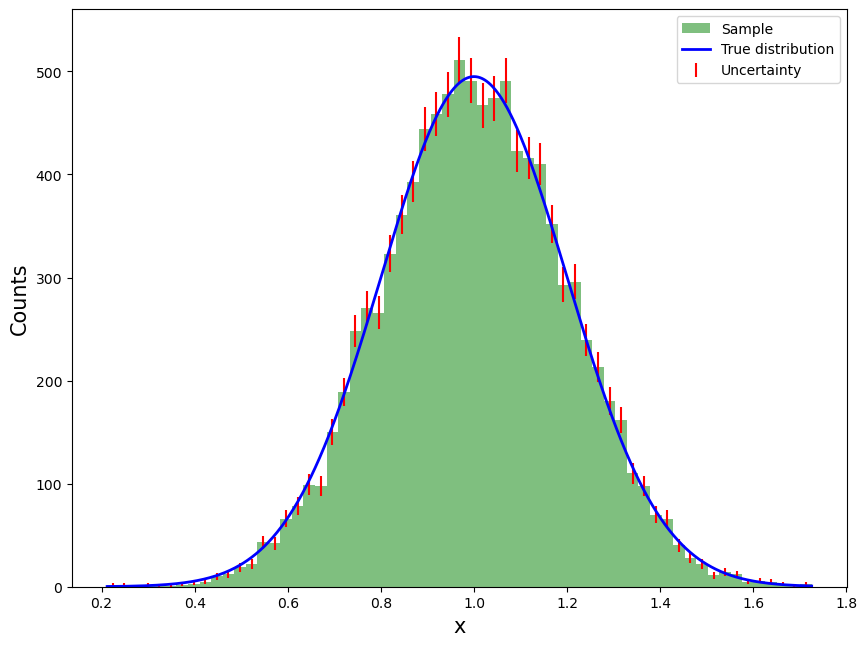

In [14]:
plot_one(1.0, 0.2, 10000)

## Problem 2

In [100]:
def plot_two(mu, gamma, size):
    #Defining sample
    np.random.seed(60)
    sample = cauchy(mu, gamma).rvs(size)

    #General
    plt.figure(figsize=(10, 7.5))
    plt.xlim(mu - 10*gamma, mu + 10*gamma)
    plt.hist(sample, bins="fd", histtype='stepfilled', color = 'g', alpha=0.5, label = 'Sample')

    #Uncertainity
    counts, edges = np.histogram(sample, bins="fd")

    bin_width = edges[1] - edges[0]
    centers = ((edges[:-1] + edges[1:]))/2
    errors = np.sqrt(counts)

    plt.errorbar(centers, counts, yerr = errors, color = 'r', fmt = 'None', label = 'Uncertainty')
    
    # True Distribution
    xGrid = np.linspace(sample.min(), sample.max(), 1000000)
    cauchy_dist = cauchy(mu, gamma).pdf(xGrid) * size * bin_width
    plt.plot(xGrid, cauchy_dist, ls='-', c='blue', linewidth = 2, label='True distribution') 

    #Formatting
    plt.legend()
    plt.xlabel("x", size = 15)
    plt.ylabel("Counts", size = 15)

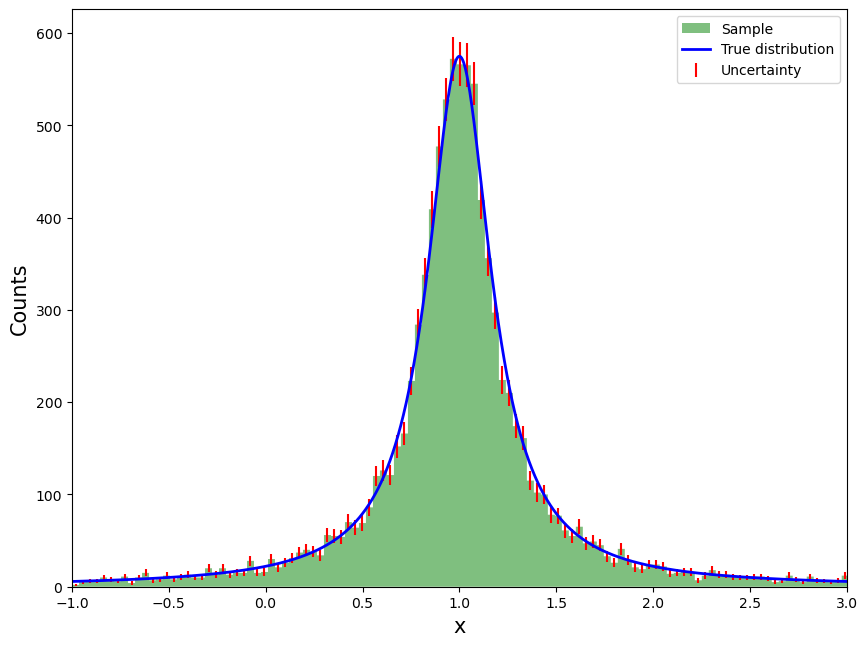

In [102]:
plot_two(1.0, 0.2, 10000)

## Problem 3

In [19]:
mu = 1.0
sigma = 0.2
gamma = 0.2
size = 10000
uncertainty = sigma / np.sqrt(size)


#Normal distribution
np.random.seed(50)
sample_normal = np.random.normal(mu, sigma, size)

mean_normal = np.mean(sample_normal)
unc_normal = np.std(sample_normal) / np.sqrt(size)


#Cauchy distribution
np.random.seed(60)
sample_cauchy = cauchy(mu, gamma).rvs(size)

mean_cauchy = np.mean(sample_cauchy)
unc_cauchy = np.std(sample_cauchy)

In [20]:
print(mean_normal, unc_normal,
      mean_cauchy, unc_cauchy)

1.0029758299615472 0.00198587805457087 1.2623647318295546 15.264073463829503


In [21]:
print(
f"""The mean of the normal distribution is {mean_normal:.4f} which is approximately equal to given mean of {mu}.
The uncertainty of the normal distribution is {unc_normal:.4f} which is approximately equal to the calculated uncertainty of {uncertainty:.4f}.
The mean of the cauchy distribution is {mean_cauchy:.4f} which is quite a bit higher than both the given mean of {mu} and of the mean of the normal distribution.
The uncertainty of the cauchy distribution is {unc_cauchy:.2f} which is extraordinarily large compaared to the calculated uncertainty of {uncertainty:.4f}.
It seems both the mean and uncertainty of the cauchy distribution are significantly impacted by outliers while the mean and uncertainty for the normal distribution are not."""
)

The mean of the normal distribution is 1.0030 which is approximately equal to given mean of 1.0.
The uncertainty of the normal distribution is 0.0020 which is approximately equal to the calculated uncertainty of 0.0020.
The mean of the cauchy distribution is 1.2624 which is quite a bit higher than both the given mean of 1.0 and of the mean of the normal distribution.
The uncertainty of the cauchy distribution is 15.26 which is extraordinarily large compaared to the calculated uncertainty of 0.0020.
It seems both the mean and uncertainty of the cauchy distribution are significantly impacted by outliers while the mean and uncertainty for the normal distribution are not.


## Problem 4

In [23]:
#Creation of data
data_four_ = {
    "Spectral Type": ["<F", "G", "K", ">M"],
    "Fraction with systems": [0.1, 0.3, 0.45, 0.7],
    "Fraction of MS stars with this spectral type": [0.1, 0.15, 0.25, 0.5]
}

data_four = pd.DataFrame(data_four_)


#Defining total probability function
def total_probability(p_A, p_B):
    result = p_A * p_B
    return result


#Running and summing function
total_df = total_probability(data_four['Fraction of MS stars with this spectral type'], data_four['Fraction with systems'])
total = total_df.sum()

In [24]:
total

0.5175

In [25]:
f"The probability a randomly chosen (== typical) main sequence star will harbor a planetary system is {total:.2f}."

'The probability a randomly chosen (== typical) main sequence star will harbor a planetary system is 0.52.'

## Problem 5

In [27]:
#Sample one
mu_one = 1.0
sigma_one = 0.1
size_one = 100

np.random.seed(70)
sample_one = np.random.normal(mu_one, sigma_one, size_one)


#Sample two
mu_two = 10.0
sigma_two = 1.0
size_two = 3

np.random.seed(80)
sample_two = np.random.normal(mu_two, sigma_two, size_two)


#Total sample
sample = np.concatenate([sample_one, sample_two])

sample_mean = np.mean(sample)
sample_median = np.median(sample)

In [28]:
print(sample_mean, sample_median)

1.2814510282965905 0.9855819074390377


In [29]:
print(f"""
The mean of the extended sample is approximately {sample_mean:.4f} and the median of the extended sample is approximately {sample_median:.4f}.
The mean has been significantly impacted by the 3 added values becoming much higher than the first sample's given mean (1.0). 
The median is much closer to the first sample's given mean (1.0) meaning the 3 added values did not have a significant impact on it.
The 3 added points are outliers in the extended sample. The mean is sensitive to outliers while the median is not as sensitive which is reflected in the above values.
""")


The mean of the extended sample is approximately 1.2815 and the median of the extended sample is approximately 0.9856.
The mean has been significantly impacted by the 3 added values becoming much higher than the first sample's given mean (1.0). 
The median is much closer to the first sample's given mean (1.0) meaning the 3 added values did not have a significant impact on it.
The 3 added points are outliers in the extended sample. The mean is sensitive to outliers while the median is not as sensitive which is reflected in the above values.



## Problem 6

The probability is .5 as you are randomly choosing one of two options (car vs goat) of which n = 1 for each. P(car) = number of car / total number of outcomes = 1 / 2

## Problem 7

In [33]:
data_seven_ = {
    "Door 1 (chosen)": ["Car", "Goat", "Goat"],
    "Door 2": ["Goat", "Car", "Goat"],
    "Door 3": ["Goat", "Goat", "Car"],
    "Staying at door #1": ["Wins car", "Wins goat", "Wins goat"],
    "Switching doors": ["Wins goat", "Wins car", "Wins car"]
}

data_seven = pd.DataFrame(data_seven_)

data_seven

,Door 1 (chosen),Door 2,Door 3,Staying at door #1,Switching doors
0,Car,Goat,Goat,Wins car,Wins goat
1,Goat,Car,Goat,Wins goat,Wins car
2,Goat,Goat,Car,Wins goat,Wins car


If you wish to win the car, switching doors gives you a better chance (2/3) instead of staying (1/3).

## Problem 8

In [ ]:
def plot_eight(mu, sigma, size):
    np.random.seed(100)
    sample = np.random.normal(mu, sigma, size)

    muGrid = np.linspace(mu - 5 * (sigma / np.sqrt(size)), mu + 5 * (sigma / np.sqrt(size)), 1000000)
    dx = muGrid[1] - muGrid[0]
    likelihood = [np.prod(norm(mu, sigma).pdf(sample)) for mu in muGrid]
    norm_likelihood = likelihood / (np.sum(likelihood) * dx)
    
    plt.plot(muGrid, norm_likelihood, label = 'Likelihood (normalized)')


    x_bar = np.sum(sample) / size
    uncertainty = np.std(sample) / np.sqrt(size)
    
    prediction = norm(x_bar, uncertainty).pdf(muGrid)
    plt.plot(muGrid, prediction, color = 'red', label = 'N($\overline{x}$, $\sigma_\overline{x}$)')

    plt.legend()

In [ ]:
plot_eight(1.0, 0.1, 10)

The peak of pdf of N($\overline{x}$, $\sigma_\overline{x}$) is slightly higher than the likelihood function and the width is less than that of the likelihood function. If you take the log of both, the shapes are nearly identical, just shifted.

## Problem 9

In [40]:
def binomal(k, b, N):
    result = (math.factorial(N) / (math.factorial(k) * math.factorial(N - k))) * (b ** k) * ((1 - b) ** (N - k))
    return result

    #k = observed black holes
    #N = observed galaxies
    #b = probability of success (30%)

In [41]:
sum(binomal(k, b = 0.3 , N = 10) for k in range(6))

0.9526510125999995

In [42]:
sum(binomal(k, b = 0.3 , N = 100) for k in range(51))

0.9999909653137987

In [43]:
sum(binomal(k, b = 0.3 , N = 1000) for k in range(501))

0.9999999999999445

## Problem 10

probability distribution function (pdf): Describes the relative likelihood of obtaining a particular value. The integral of the whole pdf is 1. For a continuous variable, the probability of obtaining a particular range of values in given by taking the integral of the pdf between those two points.    
- Population pdf: "true" pdf of the entire population (not possible to actually achieve)
- Empirical pdf: pdf based on observed data (sample)

The law of total probability states $p(A) = \sum_ip(A|B_i)p(B_i)$. Weighted averages of the conditional probabilities of A occured given event B

A marginal distribution is the pdf of some measurement $x$ irrespective of another measurement $y$

It is better to use the median than the mean as an estimator of location parameter when your distribution has many outliers or is heavily skewed. The median and IQR are "more robust estimators of the location and scale parameters than the mean and the standard deviation."

Accuracy is the measure of how close a measurement value is to the "true value" while precision is how close each measurement value is to each other (grouped-togetherness)

Central Limit Theorem: A sample of $N$ values drawn from some arbitrary $h(x)$ characterized by $\mu$ and $\sigma$ will approximately follow a Gaussian distribution $N(\mu, \sigma/\sqrt N)$ that improves as the sample size, $N$, increases. This is important because it tells us our accuracy will improve by $\sqrt N$ regardless of $h(x)$

The uncertainty, $\sigma_\overline{x}$, is equal to $\frac{s}{\sqrt N}$ where $s$ is the standard deviation of the sample and $N$ is the sample size

A histogram is a way to visualize data by sorting the data into bins of varying or constant width. It can be used to draw conclusions and estimate a model, however, there are many factors (such as bin width, bin placement) that can show misleading representations of the data.

One can estimate the location parameter, one of two ways. If the type of data and $\sigma$ is known, you can rearrange the likelihood function ($L$) to estimate $\mu$. If $\sigma$ in unknown, one can estimate $mu$ using the Maximum Likelihood Method by plotting $\mu$ vs $\sigma$ and visualizing the natural log of the likelihood function ($\ln(L)$) on top of it. It shows the likelihood of a range of $\mu$ and $\sigma$ values (see Figure 5.4)


$$L \equiv p(\{x_i\}|\mu,\sigma) = \prod_{i=1}^N \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma^2}\right).$$

One could measure the goodness of fit by comparing the overall model to the measured data. One could do this with $\chi^2$ and the likelihood function ($L$) for Gaussian distributions or other methods such as the linear regression model ($r$ I believe)